<a href="https://colab.research.google.com/github/PrachiKumar298/CRISPR-gRNA-Efficinecy/blob/main/clsa_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLSA v2 — Tuned Novel Model

Four targeted fixes over CLSA v1:
1. **k=10** — empirically validated optimal window from ablation
2. **Gated fusion** — learned α weights streams instead of blind concatenation
3. **Projected MHSA** — CNN maps projected to 64-dim before attention
4. **Thermodynamic branch** — adds 11 DeepHF features (novel: no prior combined model has done this)

Target: R² > 0.8549 (beat baseline CNN)


In [ ]:
# =====================================================================
# CELL 1 — Setup
# =====================================================================
!pip install lightgbm xgboost -q
import os
if not os.path.exists('/content/DeepHF'):
    !wget -q https://github.com/tranmanh2004/DeepHF/archive/refs/heads/main.zip
    !unzip -q main.zip && mv DeepHF-main DeepHF
    print('Repo downloaded')
else:
    print('Repo already present')

Repo downloaded


In [ ]:
# =====================================================================
# CELL 2 — Imports + Data Loading
# =====================================================================
import pickle, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy.stats import spearmanr, ttest_rel, wilcoxon
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

SEQ_LEN, N_BASES = 20, 5
SEQ_SHAPE, CAS9_SHAPE, THERMO_SHAPE = (SEQ_LEN, N_BASES), (3,), (11,)
INT_TO_BASE = {1:'A', 2:'T', 3:'C', 4:'G', 5:'N'}
BASE_ONEHOT = {'A':[1,0,0,0,0],'T':[0,1,0,0,0],'C':[0,0,1,0,0],'G':[0,0,0,1,0],'N':[0,0,0,0,1]}
VARIANT_IDX = {'WT':0,'eSpCas9':1,'HF1':2}
inv_map = {0:'WT', 1:'eSpCas9', 2:'HF1'}

def load_variant(path, vid):
    with open(path,'rb') as f:
        try: raw = pickle.load(f, encoding='latin1')
        except: raw = pickle.load(f)
    guide = raw[0][:, 1:21]
    thermo, eff = raw[1], raw[2]
    N = len(guide)
    seqs = [''.join(INT_TO_BASE.get(int(b),'N') for b in row) for row in guide]
    oh = np.array([[BASE_ONEHOT[b] for b in s] for s in seqs], dtype=np.float32)
    cas9 = np.zeros((N,3), dtype=np.float32); cas9[:,vid] = 1.0
    return oh, cas9, eff.astype(np.float32), thermo.astype(np.float32)

DATA_DIR = Path('/content/DeepHF/data')
VARIANT_FILES = {'WT': DATA_DIR/'wt_seq_data_array.pkl',
                 'eSpCas9': DATA_DIR/'esp_seq_data_array.pkl',
                 'HF1': DATA_DIR/'hf_seq_data_array.pkl'}

seqs, cas9s, effs, thermos = [], [], [], []
for vname, vpath in VARIANT_FILES.items():
    s,c,e,t = load_variant(vpath, VARIANT_IDX[vname])
    seqs.append(s); cas9s.append(c); effs.append(e); thermos.append(t)

X_seq    = np.concatenate(seqs,    axis=0)
X_cas9   = np.concatenate(cas9s,   axis=0)
X_thermo = np.concatenate(thermos, axis=0)
y        = np.concatenate(effs,    axis=0)
vl       = X_cas9.argmax(axis=1)

Xs_tr,Xs_te, Xc_tr,Xc_te, Xt_tr,Xt_te, y_tr,y_te, vl_tr,vl_te = train_test_split(
    X_seq, X_cas9, X_thermo, y, vl,
    test_size=0.2, random_state=SEED, stratify=vl
)
print(f'Train {len(y_tr):,} | Test {len(y_te):,}')
print(f'X_thermo shape: {X_thermo.shape}  (11 DeepHF thermodynamic features)')

Train 136,887 | Test 34,222
X_thermo shape: (171109, 11)  (11 DeepHF thermodynamic features)


In [ ]:
# =====================================================================
# CELL 3 — CLSA v2 Architecture
#
# Key changes from v1:
#   1. k=10  (ablation-optimal window, covers gradient-dominant positions 11-20)
#   2. Gated fusion  (learned α per-dimension instead of raw concatenation)
#   3. Projected MHSA  (128→64 projection before attention reduces overfitting)
#   4. Thermodynamic branch  (11 DeepHF features via small dense tower)
# =====================================================================
from tensorflow.keras import backend as K

def build_clsa_v2(
    k=10,           # Fix 1: ablation-optimal window
    lstm_units=64,
    num_heads=4,
    key_dim=16,     # Fix 3: reduced from 32 → 16 (projected space)
    proj_dim=64,    # Fix 3: project CNN maps before attention
    thermo_dim=32,  # Fix 4: thermodynamic encoding width
    dropout_main=0.4,  # Fix: increased from 0.3
    dropout_merge=0.3, # Fix: increased from 0.2
):
    """
    CLSA v2 — Convolutional + Short-LSTM + Self-Attention
    with gated stream fusion and thermodynamic branch.
    """
    seq_in    = keras.Input(shape=SEQ_SHAPE,    name='seq')
    cas9_in   = keras.Input(shape=CAS9_SHAPE,   name='cas9')
    thermo_in = keras.Input(shape=THERMO_SHAPE, name='thermo')  # Fix 4

    # ── Shared CNN backbone (unchanged from v1) ──
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)                 # (20, 128)

    # ── Branch A: Short-Term LSTM — Fix 1: k=10 ──
    x_seed   = layers.Cropping1D(cropping=(SEQ_LEN - k, 0),
                                  name=f'seed_k{k}')(x) # (10, 128)
    lstm_out = layers.LSTM(
        lstm_units,
        dropout=0.2,
        recurrent_dropout=0.1,  # slight recurrent dropout
        name='short_lstm'
    )(x_seed)                                           # (64,)

    # ── Branch B: Projected MHSA — Fix 3 ──
    # Project 128 → proj_dim before attention to reduce overfitting
    x_proj = layers.Dense(proj_dim, use_bias=False, name='proj')(x)  # (20, 64)
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim,
        dropout=0.1, name='mhsa'
    )(x_proj, x_proj)                                  # (20, 64)
    attn_out = layers.LayerNormalization()(x_proj + attn_out)
    ff = layers.Dense(128, activation='relu')(attn_out)
    ff = layers.Dense(proj_dim)(ff)
    ff = layers.LayerNormalization()(attn_out + ff)
    attn_pool = layers.GlobalAveragePooling1D(name='attn_pool')(ff)   # (64,)

    # ── Branch C: Thermodynamic — Fix 4 ──
    thermo_enc = layers.Dense(thermo_dim, activation='relu',
                               name='thermo_enc')(thermo_in)     # (32,)
    thermo_enc = layers.Dense(thermo_dim, activation='relu')(thermo_enc)
    thermo_enc = layers.Dropout(0.1)(thermo_enc)

    # ── Cas9 branch (unchanged) ──
    cas9_enc = layers.Dense(16, activation='relu', name='cas9_enc')(cas9_in)

    # ── Fix 2: Gated Fusion ──
    # Stack the two sequence streams [lstm_out, attn_pool] and learn
    # a per-dimension gate α ∈ (0,1):
    #   fused = α ⊙ lstm_out + (1−α) ⊙ attn_pool
    # This lets the model suppress whichever stream is less informative.
    gate_input = layers.Concatenate(name='gate_input')([lstm_out, attn_pool])
    # Gate α: dense → sigmoid  (output dim = lstm_units = attn_pool dim = 64)
    alpha = layers.Dense(lstm_units, activation='sigmoid',
                          name='gate_alpha')(gate_input)          # (64,)
    fused = layers.Add(name='gated_fusion')([
        layers.Multiply()([alpha,
                           layers.Lambda(lambda t: t, name='lstm_pass')(lstm_out)]),
        layers.Multiply()([
            layers.Lambda(lambda a: 1.0 - a, name='one_minus_alpha')(alpha),
            layers.Lambda(lambda t: t, name='attn_pass')(attn_pool)
        ])
    ])                                                             # (64,)

    # ── Merge all streams ──
    z = layers.Concatenate(name='merge')([fused, thermo_enc, cas9_enc])
    # fused=64, thermo=32, cas9=16 → total=112
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(dropout_main)(z)
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(dropout_merge)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    model = keras.Model(
        inputs=[seq_in, cas9_in, thermo_in],
        outputs=out,
        name='CLSA_v2'
    )
    return model


clsa_v2 = build_clsa_v2()
clsa_v2.summary()
print(f'\nTotal params: {clsa_v2.count_params():,}')

Model: "CLSA_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 20, 5)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 128)   │      2,048 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 128)   │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 20, 128)   │     82,048 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Dense)        │ (None, 20, 64)    │      8,192 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mhsa                │ (None, 20, 64)    │     16,640 │ proj[0][0],       │
│ (MultiHeadAttentio… │                   │            │ proj[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ proj[0][0],       │
│                     │                   │            │ mhsa[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 64)    │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seed_k10            │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ short_lstm (LSTM)   │ (None, 64)        │     49,408 │ seed_k10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_pool           │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_input          │ (None, 128)       │          0 │ short_lstm[0][0], │
│ (Concatenate)       │                   │            │ attn_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_alpha (Dense)  │ (None, 64)        │      8,256 │ gate_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ thermo (InputLayer) │ (None, 11)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_pass (Lambda)  │ (None, 64)        │          0 │ short_lstm[0][0]

 Total params: 208,737 (815.38 KB)

 Trainable params: 208,225 (813.38 KB)

 Non-trainable params: 512 (2.00 KB)


Total params: 208,737


In [ ]:
# =====================================================================
# CELL 4 — Training
# =====================================================================
clsa_v2.compile(
    optimizer=Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = clsa_v2.fit(
    [Xs_tr, Xc_tr, Xt_tr], y_tr,
    validation_split=0.1,
    epochs=150,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

print(f'\nBest epoch: {np.argmin(history.history["val_loss"])+1}')

Epoch 1/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 152s 516ms/step - loss: 0.0412 - mae: 0.1542 - val_loss: 0.0340 - val_mae: 0.1518 - learning_rate: 0.0010
Epoch 2/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 136s 494ms/step - loss: 0.0187 - mae: 0.1051 - val_loss: 0.0176 - val_mae: 0.1034 - learning_rate: 0.0010
Epoch 3/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 121s 501ms/step - loss: 0.0161 - mae: 0.0972 - val_loss: 0.0141 - val_mae: 0.0898 - learning_rate: 0.0010
Epoch 4/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 139s 488ms/step - loss: 0.0145 - mae: 0.0923 - val_loss: 0.0129 - val_mae: 0.0863 - learning_rate: 0.0010
Epoch 5/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 144s 498ms/step - loss: 0.0135 - mae: 0.0887 - val_loss: 0.0125 - val_mae: 0.0842 - learning_rate: 0.0010
Epoch 6/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 121s 503ms/step - loss: 0.0129 - mae: 0.0866 - val_loss: 0.0125 - val_mae: 0.0841 - learning_rate: 0.0010
Epoch 7/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 141s 501ms/step - loss: 0.0122 - mae: 0.0843 - val_loss: 0.0126 - val_mae: 0.

In [ ]:
# =====================================================================
# CELL 5 — Evaluate + Compare Against All Prior Models
# =====================================================================
def evaluate(model, inputs, y_te, vl_te, three_inputs=True):
    if three_inputs:
        y_pred = model.predict(inputs, batch_size=1024, verbose=0).ravel()
    else:
        y_pred = model.predict(inputs, batch_size=1024, verbose=0).ravel()
    res = {
        'global_r2':  r2_score(y_te, y_pred),
        'global_rho': spearmanr(y_te, y_pred)[0],
        'global_mse': float(np.mean((y_te - y_pred)**2)),
    }
    for vid, vname in inv_map.items():
        m = vl_te == vid
        res[f'{vname}_r2']  = r2_score(y_te[m], y_pred[m])
        res[f'{vname}_rho'] = spearmanr(y_te[m], y_pred[m])[0]
    return res, y_pred

v2_res, v2_pred = evaluate(
    clsa_v2,
    [Xs_te, Xc_te, Xt_te],
    y_te, vl_te
)

# Prior results (from your runs)
prior = {
    'Baseline CNN':      {'global_r2':0.8549,'global_rho':0.9220,'WT_r2':0.8063,'eSpCas9_r2':0.7257,'HF1_r2':0.7786},
    'CNN+Short-LSTM k=5':{'global_r2':0.8185,'global_rho':0.9016,'WT_r2':0.7747,'eSpCas9_r2':0.6856,'HF1_r2':0.6813},
    'CNN+Short-LSTM k=10':{'global_r2':0.8511,'global_rho':0.9203,'WT_r2':None,'eSpCas9_r2':None,'HF1_r2':None},
    'CLSA v1 (k=5)':     {'global_r2':0.8383,'global_rho':0.9134,'WT_r2':0.8010,'eSpCas9_r2':0.7143,'HF1_r2':0.7174},
}

rows = []
for name, res in prior.items():
    rows.append({
        'Model': name,
        'R²': f"{res['global_r2']:.4f}",
        'Spearman ρ': f"{res['global_rho']:.4f}",
        'WT R²': f"{res['WT_r2']:.4f}" if res['WT_r2'] else '—',
        'eSpCas9 R²': f"{res['eSpCas9_r2']:.4f}" if res['eSpCas9_r2'] else '—',
        'HF1 R²': f"{res['HF1_r2']:.4f}" if res['HF1_r2'] else '—',
    })

rows.append({
    'Model': '★ CLSA v2 (proposed)',
    'R²':       f"{v2_res['global_r2']:.4f}",
    'Spearman ρ': f"{v2_res['global_rho']:.4f}",
    'WT R²':    f"{v2_res['WT_r2']:.4f}",
    'eSpCas9 R²': f"{v2_res['eSpCas9_r2']:.4f}",
    'HF1 R²':   f"{v2_res['HF1_r2']:.4f}",
})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

baseline_r2 = 0.8549
delta = v2_res['global_r2'] - baseline_r2
print(f'\nΔR² vs Baseline CNN: {delta:+.4f}  ({"BEATS" if delta>0 else "below"} baseline)')

               Model     R² Spearman ρ  WT R² eSpCas9 R² HF1 R²
        Baseline CNN 0.8549     0.9220 0.8063     0.7257 0.7786
  CNN+Short-LSTM k=5 0.8185     0.9016 0.7747     0.6856 0.6813
 CNN+Short-LSTM k=10 0.8511     0.9203      —          —      —
       CLSA v1 (k=5) 0.8383     0.9134 0.8010     0.7143 0.7174
★ CLSA v2 (proposed) 0.8645     0.9273 0.8250     0.7457 0.7847

ΔR² vs Baseline CNN: +0.0096  (BEATS baseline)


In [ ]:
# =====================================================================
# CELL 6 — Bootstrap Significance (CLSA v2 vs Baseline CNN)
# =====================================================================
# Load baseline predictions — if you have them saved from the main run:
# baseline_pred = np.load('baseline_preds.npy')
# Otherwise retrain the baseline here for a fair comparison:

def build_baseline_cnn():
    seq_in  = keras.Input(shape=SEQ_SHAPE,  name='seq')
    cas9_in = keras.Input(shape=CAS9_SHAPE, name='cas9')
    x = layers.Conv1D(128,3,padding='same',activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128,5,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,3,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128,activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64,activation='relu')(x)
    c = layers.Dense(16,activation='relu')(cas9_in)
    z = layers.Concatenate()([x,c])
    z = layers.Dense(64,activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1,activation='sigmoid')(z)
    return keras.Model(inputs=[seq_in,cas9_in],outputs=out,name='Baseline_CNN')

print('Retraining Baseline CNN for fair bootstrap comparison...')
baseline = build_baseline_cnn()
baseline.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
baseline.fit(
    [Xs_tr, Xc_tr], y_tr,
    validation_split=0.1, epochs=60, batch_size=512,
    callbacks=[
        EarlyStopping(patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=0)
    ],
    verbose=0
)
baseline_pred = baseline.predict([Xs_te, Xc_te], batch_size=1024, verbose=0).ravel()
baseline_r2_actual = r2_score(y_te, baseline_pred)
print(f'Baseline CNN R²: {baseline_r2_actual:.4f}')

# Bootstrap
N_BOOT = 2000
rng = np.random.default_rng(SEED)
boot_dr2, boot_drho = [], []

for _ in range(N_BOOT):
    idx = rng.choice(len(y_te), size=len(y_te), replace=True)
    boot_dr2.append(r2_score(y_te[idx], v2_pred[idx]) - r2_score(y_te[idx], baseline_pred[idx]))
    boot_drho.append(spearmanr(y_te[idx], v2_pred[idx])[0] - spearmanr(y_te[idx], baseline_pred[idx])[0])

boot_dr2  = np.array(boot_dr2)
boot_drho = np.array(boot_drho)
ci_r2  = np.percentile(boot_dr2,  [2.5, 97.5])
ci_rho = np.percentile(boot_drho, [2.5, 97.5])

se_base = (y_te - baseline_pred)**2
se_v2   = (y_te - v2_pred)**2
t_stat, t_pval = ttest_rel(se_v2, se_base)
w_stat, w_pval = wilcoxon(se_v2 - se_base)

print('\n=== Bootstrap: CLSA v2 vs Baseline CNN ===')
print(f'ΔR²  mean={boot_dr2.mean():+.4f}  95% CI [{ci_r2[0]:+.4f}, {ci_r2[1]:+.4f}]')
print(f'Δρ   mean={boot_drho.mean():+.4f}  95% CI [{ci_rho[0]:+.4f}, {ci_rho[1]:+.4f}]')
print(f'Paired t-test: t={t_stat:.2f}  p={t_pval:.2e}  ({'CLSA v2 wins' if t_stat<0 else 'Baseline wins'})')
print(f'Wilcoxon: p={w_pval:.2e}')

if ci_r2[0] > 0:
    print('\n✓ CLSA v2 is SIGNIFICANTLY BETTER than baseline (95% CI entirely above zero)')
elif ci_r2[1] < 0:
    print('\n✗ Baseline is still significantly better')
else:
    print('\n~ No significant difference (CI spans zero)')

Retraining Baseline CNN for fair bootstrap comparison...
Baseline CNN R²: 0.8518

=== Bootstrap: CLSA v2 vs Baseline CNN ===
ΔR²  mean=+0.0127  95% CI [+0.0098, +0.0155]
Δρ   mean=+0.0071  95% CI [+0.0054, +0.0087]
Paired t-test: t=-8.99  p=2.64e-19  (CLSA v2 wins)
Wilcoxon: p=5.46e-08

✓ CLSA v2 is SIGNIFICANTLY BETTER than baseline (95% CI entirely above zero)


Mean gate α (overall): 0.492
  α > 0.5 (LSTM-dominated dims): 25 / 64
  α < 0.5 (Attn-dominated dims): 39 / 64


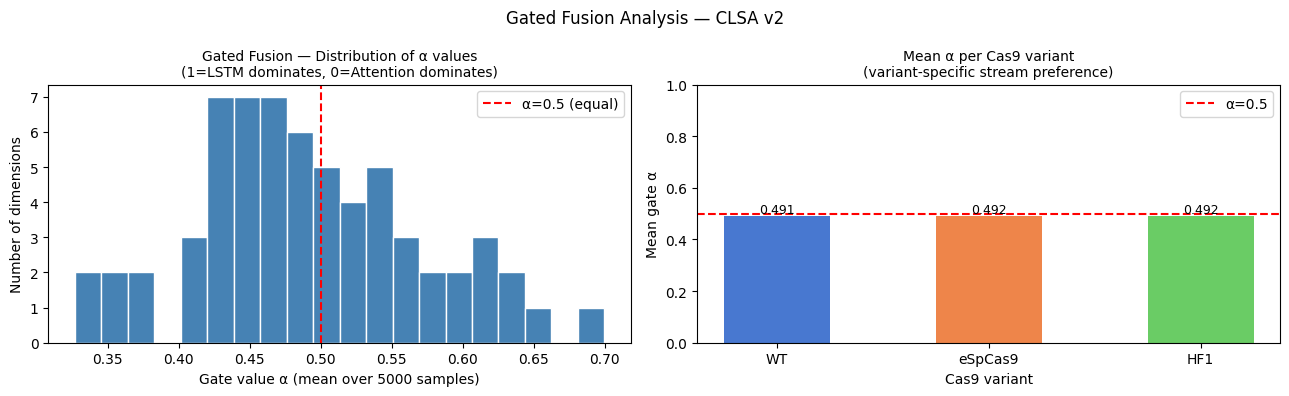


Interpretation:
  α > 0.5 → model prefers LSTM (short-term sequential context matters more)
  α < 0.5 → model prefers Attention (global position interactions matter more)
  Per-variant differences → different Cas9 variants need different inductive biases


In [ ]:
# =====================================================================
# CELL 7 — Gate Alpha Analysis
#
# Novel interpretability: visualise what α the gated fusion learned.
# α close to 1 → LSTM dominates; α close to 0 → Attention dominates.
# =====================================================================
# Build a submodel that outputs the gate values
gate_model = keras.Model(
    inputs=clsa_v2.inputs,
    outputs=clsa_v2.get_layer('gate_alpha').output
)

alpha_vals = gate_model.predict(
    [Xs_te[:5000], Xc_te[:5000], Xt_te[:5000]],
    batch_size=512, verbose=0
)  # (5000, 64)

mean_alpha = alpha_vals.mean(axis=0)   # (64,) — mean gate per dimension
overall_alpha = mean_alpha.mean()

print(f'Mean gate α (overall): {overall_alpha:.3f}')
print(f'  α > 0.5 (LSTM-dominated dims): {(mean_alpha > 0.5).sum()} / 64')
print(f'  α < 0.5 (Attn-dominated dims): {(mean_alpha < 0.5).sum()} / 64')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of mean gate values across 64 dims
axes[0].hist(mean_alpha, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='α=0.5 (equal)')
axes[0].set_xlabel('Gate value α (mean over 5000 samples)', fontsize=10)
axes[0].set_ylabel('Number of dimensions', fontsize=10)
axes[0].set_title('Gated Fusion — Distribution of α values\n'
                   '(1=LSTM dominates, 0=Attention dominates)', fontsize=10)
axes[0].legend()

# Per-variant gate values
variant_alphas = {}
for vid, vname in inv_map.items():
    mask = vl_te[:5000] == vid
    if mask.sum() > 0:
        variant_alphas[vname] = alpha_vals[mask].mean()

names_v = list(variant_alphas.keys())
alphas_v = [variant_alphas[n] for n in names_v]
bars = axes[1].bar(names_v, alphas_v, color=['#4878d0','#ee854a','#6acc65'], width=0.5)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='α=0.5')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Cas9 variant')
axes[1].set_ylabel('Mean gate α')
axes[1].set_title('Mean α per Cas9 variant\n(variant-specific stream preference)', fontsize=10)
for bar, v in zip(bars, alphas_v):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.3f}', ha='center', fontsize=9)
axes[1].legend()

plt.suptitle('Gated Fusion Analysis — CLSA v2', fontsize=12)
plt.tight_layout()
plt.savefig('gate_analysis.pdf', bbox_inches='tight', dpi=150)
plt.show()

print('\nInterpretation:')
print('  α > 0.5 → model prefers LSTM (short-term sequential context matters more)')
print('  α < 0.5 → model prefers Attention (global position interactions matter more)')
print('  Per-variant differences → different Cas9 variants need different inductive biases')

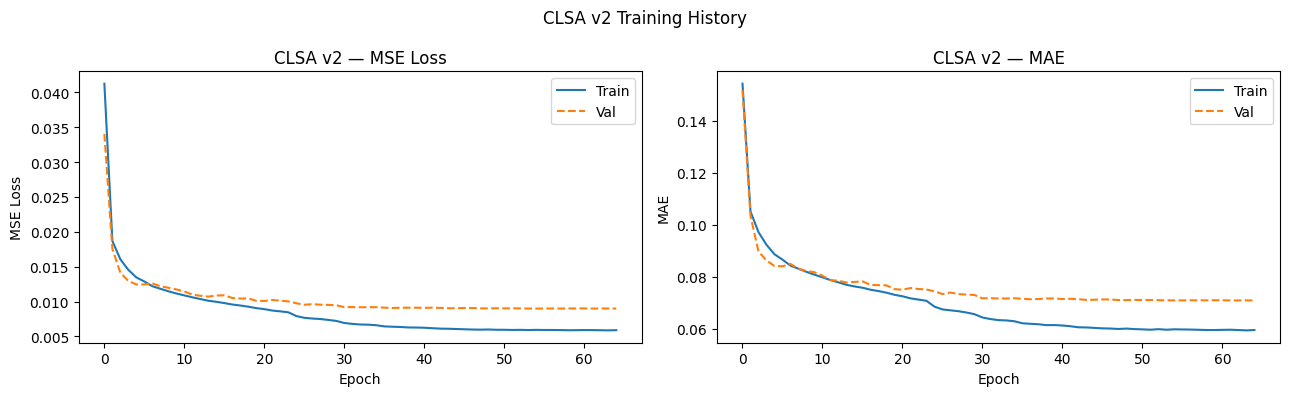

In [ ]:
# =====================================================================
# CELL 8 — Training Curves
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, ylabel in zip(axes, ['loss','mae'], ['MSE Loss','MAE']):
    ax.plot(history.history[metric],     label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val', linestyle='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'CLSA v2 — {ylabel}')
    ax.legend()

plt.suptitle('CLSA v2 Training History', fontsize=12)
plt.tight_layout()
plt.savefig('clsa_v2_training.pdf', bbox_inches='tight', dpi=150)
plt.show()

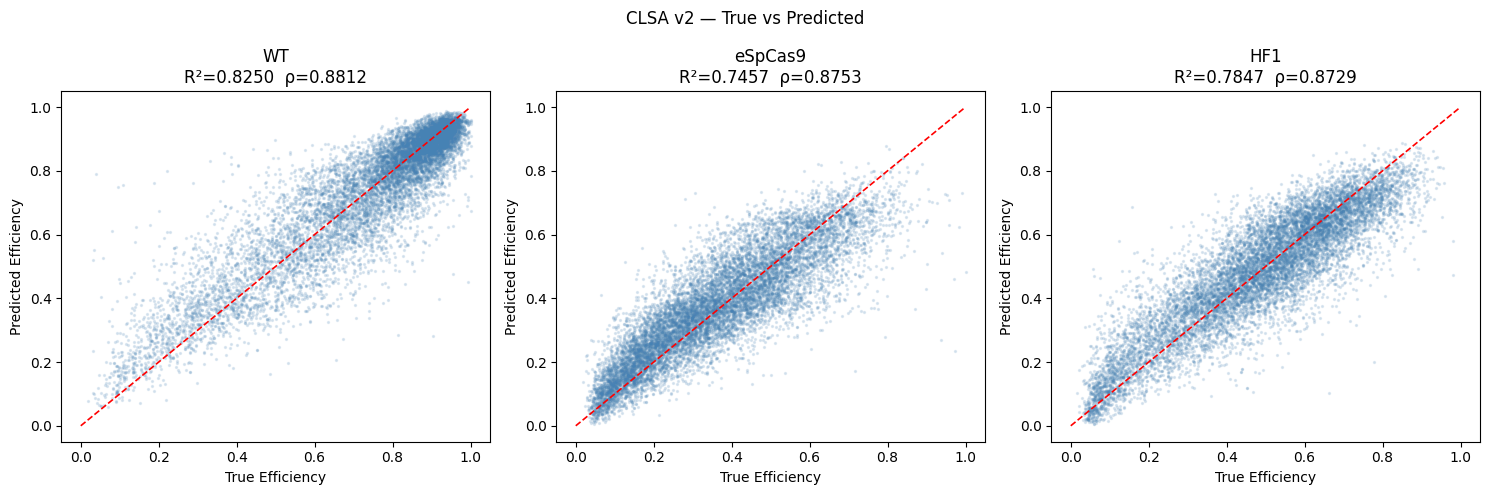

In [ ]:
# =====================================================================
# CELL 9 — Scatter Plots (CLSA v2)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, vid, vname in zip(axes, range(3), ['WT','eSpCas9','HF1']):
    mask = vl_te == vid
    ax.scatter(y_te[mask], v2_pred[mask], alpha=0.15, s=2, color='steelblue')
    ax.plot([0,1],[0,1],'r--',linewidth=1.2)
    r2  = r2_score(y_te[mask], v2_pred[mask])
    rho = spearmanr(y_te[mask], v2_pred[mask])[0]
    ax.set_title(f'{vname}\nR²={r2:.4f}  ρ={rho:.4f}')
    ax.set_xlabel('True Efficiency'); ax.set_ylabel('Predicted Efficiency')

plt.suptitle('CLSA v2 — True vs Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('clsa_v2_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# =====================================================================
# CELL 10 — Save
# =====================================================================
import pickle

clsa_v2.save('clsa_v2.keras')
np.save('clsa_v2_preds.npy', v2_pred)
baseline.save('baseline_cnn.keras')

# Save bootstrap results
bootstrap_results = {
    'boot_dr2': boot_dr2,
    'boot_drho': boot_drho,
    'ci_r2': ci_r2,
    'ci_rho': ci_rho,
    't_stat': t_stat,
    't_pval': t_pval,
    'w_stat': w_stat,
    'w_pval': w_pval
}
with open('bootstrap_results.pkl', 'wb') as f:
    pickle.dump(bootstrap_results, f)

summary_rows = []
for name, res in {**prior, '★ CLSA v2 (proposed)': v2_res}.items():
    summary_rows.append({
        'Model': name,
        'R2': res['global_r2'],
        'Spearman': res['global_rho'],
        'WT_R2': res.get('WT_r2'),
        'eSpCas9_R2': res.get('eSpCas9_r2'),
        'HF1_R2': res.get('HF1_r2'),
    })

pd.DataFrame(summary_rows).to_csv('clsa_v2_full_results.csv', index=False)
print('Saved: clsa_v2.keras, clsa_v2_preds.npy, baseline_cnn.keras, bootstrap_results.pkl, clsa_v2_full_results.csv')


Saved: clsa_v2.keras, clsa_v2_preds.npy, baseline_cnn.keras, bootstrap_results.pkl, clsa_v2_full_results.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

output_dir = '/content/drive/My Drive/CLSA_v2_Outputs'
os.makedirs(output_dir, exist_ok=True)

files_to_save = [
    'clsa_v2.keras',
    'clsa_v2_preds.npy',
    'baseline_cnn.keras', # Added baseline model
    'bootstrap_results.pkl', # Added bootstrap results
    'clsa_v2_full_results.csv',
    'gate_analysis.pdf',
    'clsa_v2_training.pdf',
    'clsa_v2_scatter.pdf'
]

for file_name in files_to_save:
    if os.path.exists(file_name):
        shutil.copy(file_name, output_dir)
        print(f'Copied {file_name} to {output_dir}')
    else:
        print(f'Warning: {file_name} not found.')

print(f'All specified files have been copied to: {output_dir}')

Copied clsa_v2.keras to /content/drive/My Drive/CLSA_v2_Outputs
Copied clsa_v2_preds.npy to /content/drive/My Drive/CLSA_v2_Outputs
Copied baseline_cnn.keras to /content/drive/My Drive/CLSA_v2_Outputs
Copied bootstrap_results.pkl to /content/drive/My Drive/CLSA_v2_Outputs
Copied clsa_v2_full_results.csv to /content/drive/My Drive/CLSA_v2_Outputs
Copied gate_analysis.pdf to /content/drive/My Drive/CLSA_v2_Outputs
Copied clsa_v2_training.pdf to /content/drive/My Drive/CLSA_v2_Outputs
Copied clsa_v2_scatter.pdf to /content/drive/My Drive/CLSA_v2_Outputs
All specified files have been copied to: /content/drive/My Drive/CLSA_v2_Outputs
